## 11. Decision Boundary

This notebook explains the dexision boundary in logistic regression.

이 노트북에서는 logistic regression의 decision boundary를 학습한다.

Logistic regression outputs a probability between 0 and 1,  
but in binary classification we still need to decide wgether the final class is 0 or 1.

logistic regression은 0과 1사이의 확률을 출력하지만,  
binary classification에서는 최종적으로 0 또는 1 클래스를 결정해야 한다.

The decision boundary is the rule that separates class 0 from class 1.

decision boundary는 class 0과 class 1을 나누는 기준이다.

## 1. Reminder: Logictic Regression Output

Logistic regression computes:

z = w*x + b

Then applies the sigmoid function:

f(x) = sigmoid(z)

즉 logistic regression은 먼저

z = w*x + b

를 계산하고 그 다음 sigmoid를 적용한다

The output f(x) is always between 0 and 1.

출력 f(x)는 항상 0과 1 사이의 값이다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# 소수점 자리를 3자리로 설정 및 지수 표현 억제
np.set_printoptions(precision=3, suppress=True)

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

## 2. From Probability to Class Presiction

A logistic regression model outputs a probability

logistic regression 모델은 확률을 출력한다.

For example:
- 0.2 means the model thinks class 1 has probability 20%
- 0.8 means the model thinks class 1 has probability 80%

예를 들어:
- 0.2는 class 1일 확률이 20%라는 뜻
- 0.8는 class 1일 확률이 80%라는 뜻

To convert probability into a class:
- if f(z) >= 0.5, predict class 1
- if f(z) < 0.5, predict class 0

확률을 클래스로 바꾸기 위해 보통 다음 기준을 사용한다:
- f(x) >= 0.5 이면 class 1
- f(x) < 0.5 이면 class 0

In [5]:
# example probability
probs = np.array([0.1, 0.3, 0.5, 0.7, 0.9])

# Convert probability to class predictions
preds = (probs >= 0.5).astype(int)

print("Probability -> prediction")
for p, preds in zip(probs, preds):
    print(f"{p:.1f} -> {preds}")

Probability -> prediction
0.1 -> 0
0.3 -> 0
0.5 -> 1
0.7 -> 1
0.9 -> 1


## 3. Why is the threshold usually 0.5?

The sigmoid function has a special property:

sigmoid(0) = 0.5

sigmoid 함수는 다음 설징을 가진다.

sigmoid(0) = 0.5

So:
- if z >= 0, then sigmoid(z) >= 0.5
- if z < 0, then sigmoid(z) < 0.5

따라서:
- z >= 0 이면 sigmoid(z) >= 0.5
- z < 0 이면 sigmoid(z) < 0.5

In [9]:
z_values = np.array([-3, -1, 0, 1, 3], dtype=float)
sig_values = sigmoid(z_values)

print("z\t sigmoid(z)")
for z, s in zip(z_values, sig_values):
    print(f"{z:>4}\t {s:.6f}")

z	 sigmoid(z)
-3.0	 0.047426
-1.0	 0.268941
 0.0	 0.500000
 1.0	 0.731059
 3.0	 0.952574


## 4. Decision Boundary

The decision boundary is the boundary where the model changes  
from predicting class 0 to predicting class 1

decision boundary는 모델이 class 0에서 class 1로 바뀌는 경계이다

Because the threshold is 0.5 and sigmoid(0) = 0.5  
the decision boundary happens when:

z = 0

threshold가 0.5이고 sigmoid(0)=0.5 이므로  
decision boundary는 결국 다음 조건에서 발생한다:

z = 0

### In one feature (one-dimensional case)

If we have only one feature x, then:

z = wx + b

The decision boundary is where:

wx + b = 0

feature가 하나인 경우,
decision boundary는 다음 식을 만족하는 x 값이다:

wx + b = 0

In [10]:
# Example parameters
w = 1.0
b = -4.0

# Decision boundary from wx + b = 0
x_boundary = -b / w

print("w =", w)
print("b =", b)
print("Decision boundary x =", x_boundary)

w = 1.0
b = -4.0
Decision boundary x = 4.0


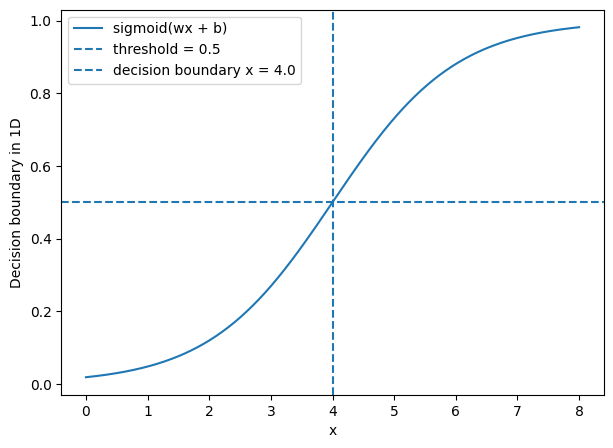

In [12]:
x = np.linspace(0, 8, 400)
z = w * x + b
y = sigmoid(z)

plt.figure(figsize=(7, 5))
plt.plot(x, y, label="sigmoid(wx + b)")
plt.axhline(0.5, linestyle='--', label="threshold = 0.5")
plt.axvline(x_boundary, linestyle='--', label=f"decision boundary x = {x_boundary:.1f}")
plt.xlabel("x")
plt.ylabel("Decision boundary in 1D")
plt.legend()
plt.show()


## 5. Interpretation of the graph

To the left of the decision boundary:
- z < 0
- sigmoid(z) < 0.5
- predict class 0

decision boundary의 왼쪽에서는:
- z < 0
- sigmoid(z) < 0.5
- class 0으로 예측

To the right of the decision boundary:
- z >= 0
- sigmoid(z) >= 0.5
- predict class 1

decision boundary의 오른쪽에서는:
- z >= 0
- sigmoid(z) >= 0.5
- class 1로 예측

In [13]:
x_test = np.array([1, 3, 4, 5, 7], dtype=float)
z_test = w * x_test + b
p_test = sigmoid(z_test)
pred_test = (p_test >= 0.5).astype(int)

x_test = np.array([1, 3, 4, 5, 7], dtype=float)
z_test = w * x_test + b
p_test = sigmoid(z_test)
pred_test = (p_test >= 0.5).astype(int)

print(" x\t z\t prob\t\t pred")
for xv, zv, pv, pred in zip(x_test, z_test, p_test, pred_test):
    print(f"{xv:>2.0f}\t {zv:>4.1f}\t {pv:.6f}\t {pred}")

 x	 z	 prob		 pred
 1	 -3.0	 0.047426	 0
 3	 -1.0	 0.268941	 0
 4	  0.0	 0.500000	 1
 5	  1.0	 0.731059	 1
 7	  3.0	 0.952574	 1


## 6. Key idea

A decision boundary is not about the sigmoid curve itself.
It is about where the model changes its class prediction.

decision boundary는 단순히 sigmoid 곡선 자체를 말하는 것이 아니라,
모델이 class prediction을 바꾸는 경계를 의미한다.

In logistic regression:
- first compute z = w·x + b
- then use sigmoid(z)
- then apply threshold 0.5

logistic regression에서는:
- 먼저 z = w·x + b 계산
- 그 다음 sigmoid(z) 적용
- 마지막으로 0.5 threshold를 사용해 class 결정

So the decision boundary comes from z = 0.

따라서 decision boundary는 결국 z = 0 에서 결정된다.

## Conclusion

Logistic regression outputs probabilities, not final classes directly.

logistic regression은 최종 class를 직접 출력하는 것이 아니라 확률을 출력한다.

To make a binary prediction, we usually use the threshold 0.5

binary prediction을 위해 보통 threshold 0.5를 사용한다

Because sigmoid(0) = 0.5, the decision boundary occurs where z = 0

sigmoid(0)=0.5 이므로 decision boundary는 z = 0 에서 발생한다

In one-dimensional logistic regression:
- z = wx + b
- decision boundary: wx + b = 0

1차원 logistic regression에서는:
- z = wx + b
- decision boundary: wx + b = 0